In [17]:

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset"
file_paths = [
    "https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset",
    "https://www.kaggle.com/datasets/brynja/wineuci",
    "https://www.kaggle.com/datasets/camnugent/california-housing-prices",
    "https://www.kaggle.com/datasets/arjunbhasin2013/ccdata"]

local_paths = []
for f  in file_paths:
    path = kagglehub.dataset_download(f.split('datasets/')[-1])
    local_paths.append(path)

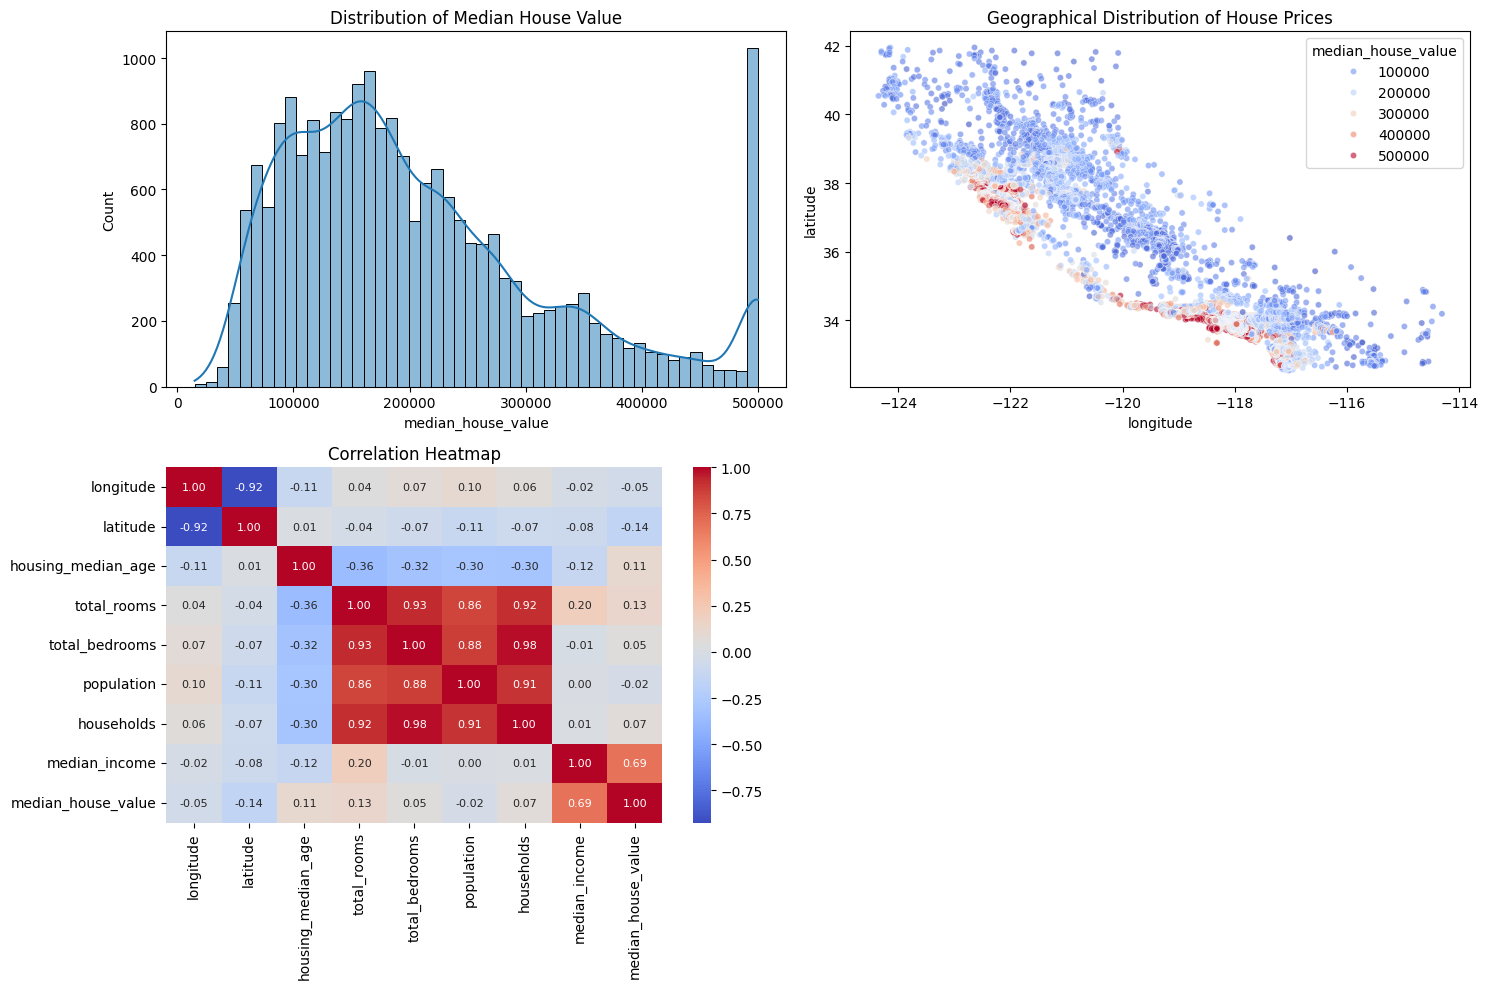

--- Regression Metrics Report ---
RMSE: $48,941.70
MAE:  $31,628.41
R²:   0.8172


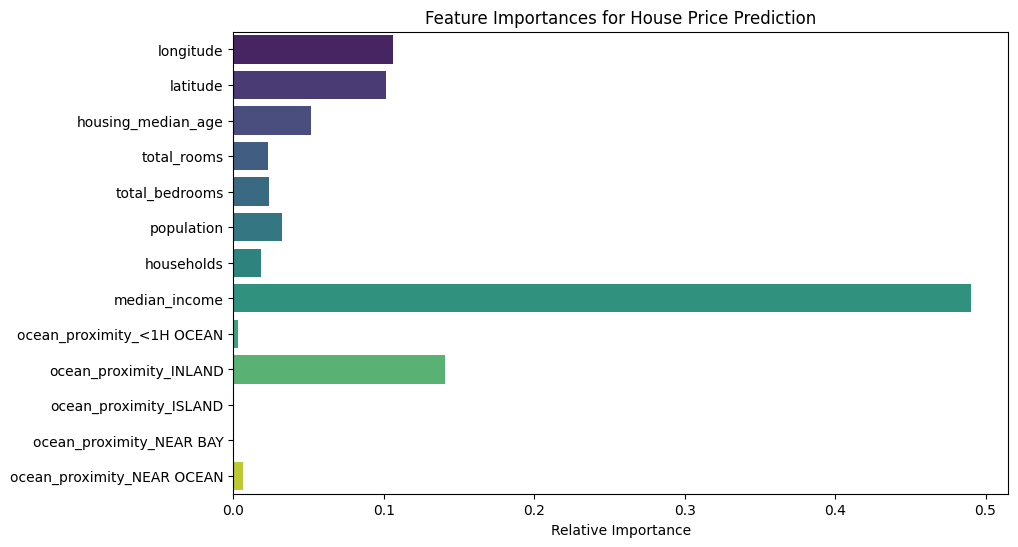

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load Data
df = pd.read_csv(local_paths[-2]+ '/housing.csv')

# 2. Thorough EDA
plt.figure(figsize=(15, 10))

# EDA Plot 1: Target Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['median_house_value'], kde=True, bins=50)
plt.title('Distribution of Median House Value')

# EDA Plot 2: Geographical Scatter Plot of Prices
plt.subplot(2, 2, 2)
sns.scatterplot(x='longitude', y='latitude', data=df, hue='median_house_value', 
                palette='coolwarm', alpha=0.6, s=20)
plt.title('Geographical Distribution of House Prices')

# EDA Plot 3: Correlation Heatmap (Numeric features only)
plt.subplot(2, 2, 3)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 3. Preprocessing & Modeling
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = ['ocean_proximity']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Using Random Forest to easily extract Feature Importance
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)

# 4. Evaluation Metrics
test_preds = model.predict(X_test)
print("--- Regression Metrics Report ---")
print(f"RMSE: ${root_mean_squared_error(y_test, test_preds):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, test_preds):,.2f}")
print(f"R²:   {r2_score(y_test, test_preds):.4f}")

# 5. Variable Importance Plot
# Extract feature names after OneHotEncoding
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

importances = model.named_steps['regressor'].feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=all_feature_names, palette='viridis')
plt.title('Feature Importances for House Price Prediction')
plt.xlabel('Relative Importance')
plt.show()

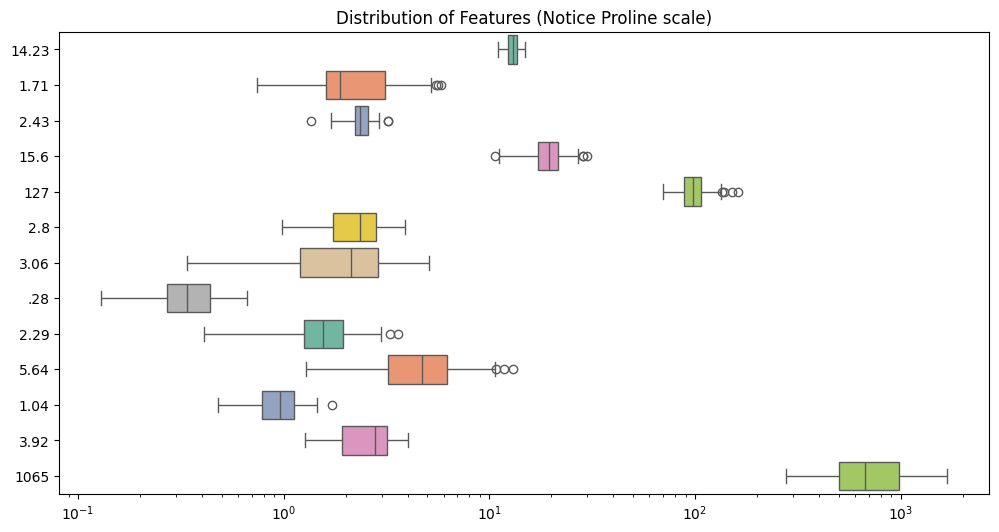

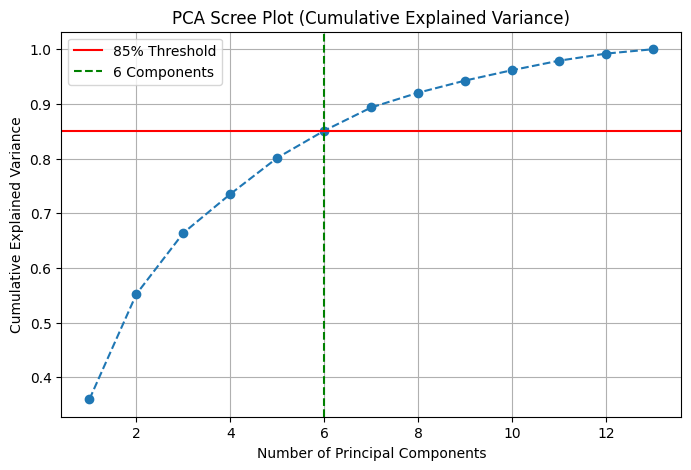

Exact number of components to explain >= 85% variance: 6


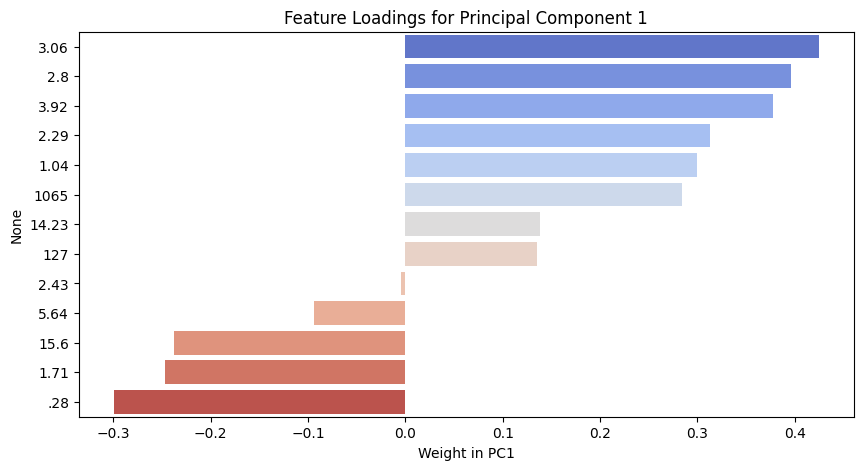

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Data
df = pd.read_csv(local_paths[1]+'/Wine.csv')
# Assuming first column is the target class 'Cultivar'
target = df.iloc[:, 0]
X = df.drop(df.columns[0], axis=1)

# 2. EDA: Boxplots to show feature scales before standardization
plt.figure(figsize=(12, 6))
sns.boxplot(data=X, orient="h", palette="Set2")
plt.title('Distribution of Features (Notice Proline scale)')
plt.xscale('log') # Log scale due to extreme differences in magnitude
plt.show()

# 3. PCA Modeling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

# 4. Scree Plot (Cumulative Variance)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle='-', label='85% Threshold')
plt.axvline(x=n_components_85, color='g', linestyle='--', label=f'{n_components_85} Components')
plt.title('PCA Scree Plot (Cumulative Explained Variance)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(f"Exact number of components to explain >= 85% variance: {n_components_85}")

# 5. Loadings (Importance of original variables in PC1)
loadings = pd.Series(pca.components_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=loadings.values, y=loadings.index, palette='coolwarm')
plt.title('Feature Loadings for Principal Component 1')
plt.xlabel('Weight in PC1')
plt.show()

## Exam C 

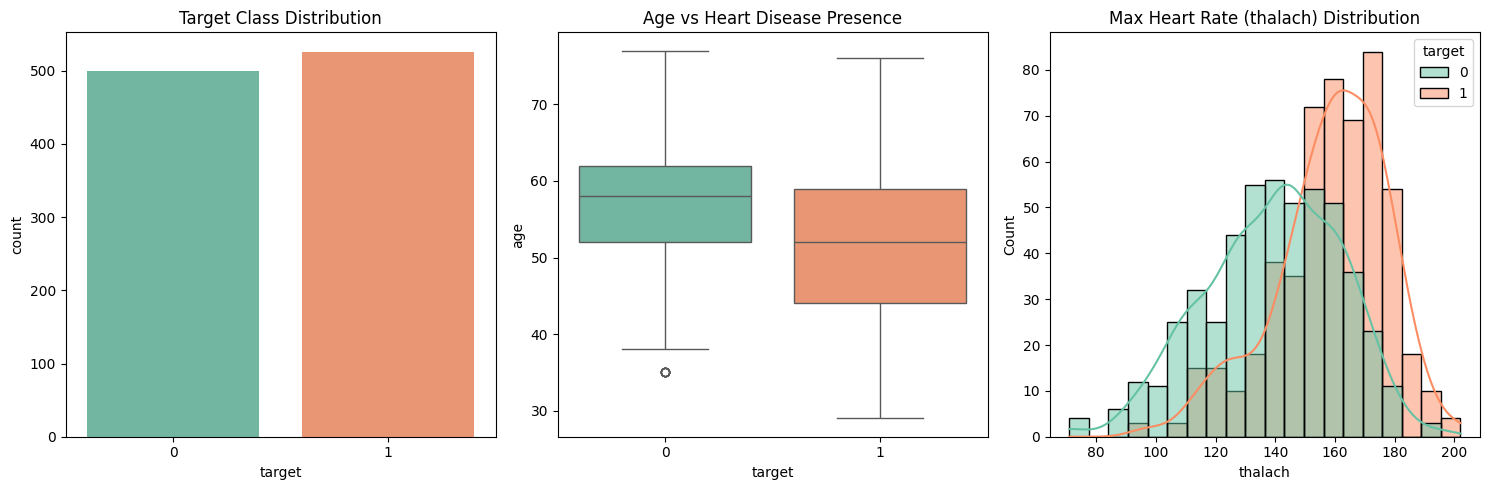

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       102
           1       0.83      0.94      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205

Test ROC-AUC Score: 0.9623



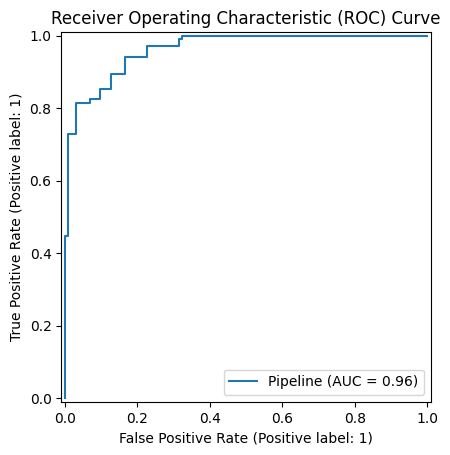

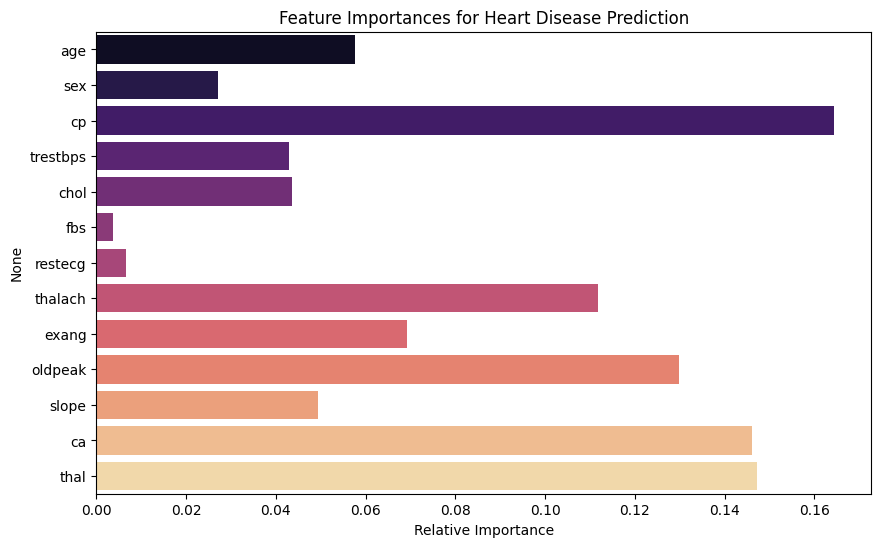

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Load Data
df = pd.read_csv(local_paths[0] + '/heart.csv')

# 2. EDA
plt.figure(figsize=(15, 5))

# EDA 1: Target Imbalance Check
plt.subplot(1, 3, 1)
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Target Class Distribution')

# EDA 2: Age vs Target
plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='age', data=df, palette='Set2')
plt.title('Age vs Heart Disease Presence')

# EDA 3: Max Heart Rate vs Target
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette='Set2')
plt.title('Max Heart Rate (thalach) Distribution')
plt.tight_layout()
plt.show()

# 3. Preprocessing & Modeling
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5))
])

model.fit(X_train, y_train)

# 4. Classification Report & Metrics
test_preds = model.predict(X_test)
test_probs = model.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, test_preds))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}\n")

# ROC Curve Plot
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

# 5. Variable Importance Plot
importances = model.named_steps['classifier'].feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=X.columns, palette='magma')
plt.title('Feature Importances for Heart Disease Prediction')
plt.xlabel('Relative Importance')
plt.show()

--- Table: Average Characteristics per Cluster ---
         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  TENURE
Cluster                                                                  
0        1012.66     270.04        596.51       3278.71    974.26   11.45
1        3551.15    7681.62        653.64       9696.94   7288.74   11.95
2        4602.45     501.86       4521.51       7546.16   3484.05   11.39
3         894.91    1236.18        210.57       4213.21   1332.19   11.59
--------------------------------------------------


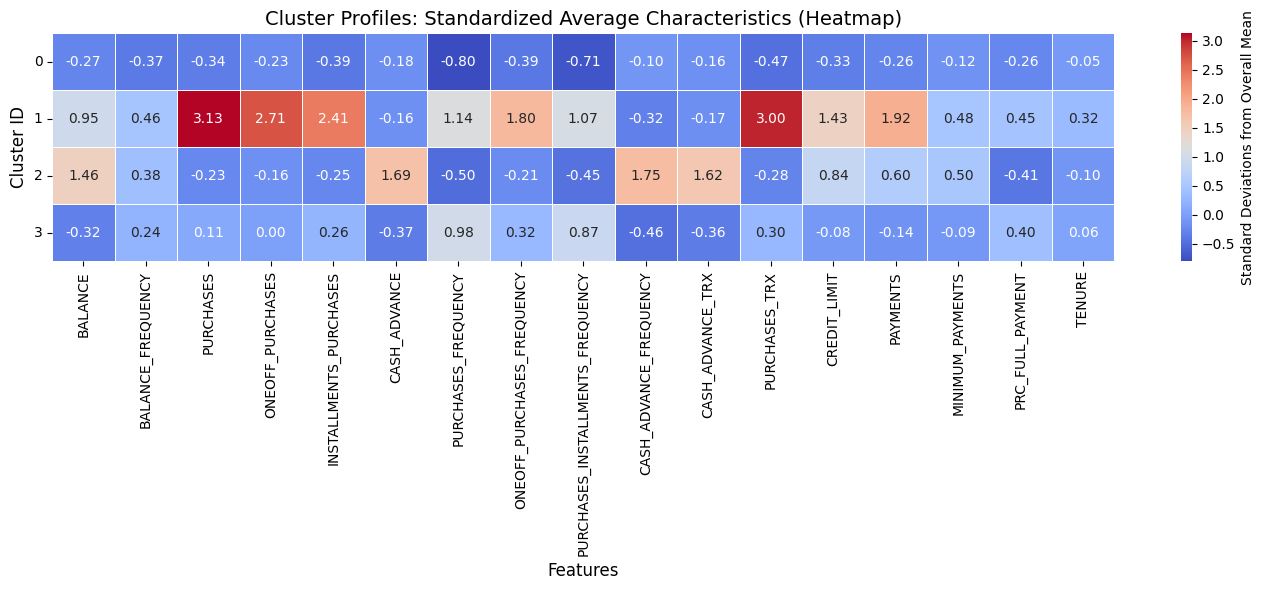

<Figure size 1200x600 with 0 Axes>

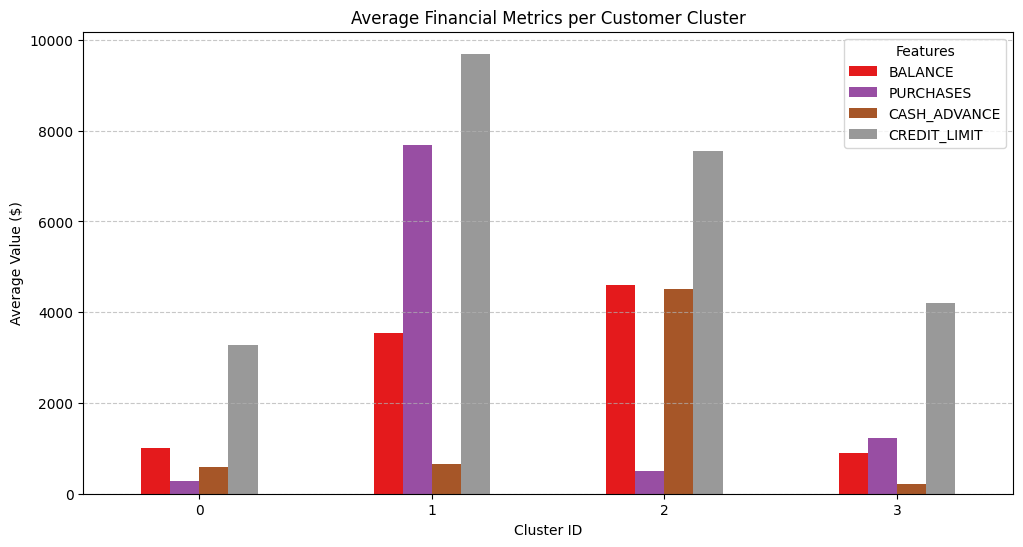

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv(local_paths[-1]+'/CC GENERAL.csv')
X = df.drop('CUST_ID', axis=1)
# 2. Handle Missing Values & Scale Data
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# ==========================================
# PART A: GENERATE THE AVERAGE CHARACTERISTICS TABLE
# ==========================================
# Group by Cluster and calculate the mean for key features
key_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
    'CREDIT_LIMIT', 'PAYMENTS', 'TENURE'
]

cluster_means = df.groupby('Cluster')[key_features].mean().round(2)

print("--- Table: Average Characteristics per Cluster ---")
print(cluster_means.to_string())
print("-" * 50)


# ==========================================
# PART B: VISUALIZE CLUSTER CHARACTERISTICS (Heatmap)
# ==========================================
# To visualize how clusters differ, it is best to look at the scaled centers.
# Positive values mean "above average" for that feature; negative means "below average".
cluster_centers_scaled = pd.DataFrame(
    kmeans.cluster_centers_, 
    columns=X.columns
)

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_centers_scaled, 
            cmap='coolwarm', 
            annot=True, 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={'label': 'Standard Deviations from Overall Mean'})

plt.title('Cluster Profiles: Standardized Average Characteristics (Heatmap)', fontsize=14)
plt.ylabel('Cluster ID', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. "Feature Importance" in Clustering: Cluster Profiles
# Calculate the mean of each feature per cluster to see what defines them
cluster_means = df.drop('CUST_ID', axis=1).groupby('Cluster').mean()
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

plt.figure(figsize=(12, 6))
cluster_means[features_to_plot].plot(kind='bar', figsize=(12, 6), colormap='Set1')
plt.title('Average Financial Metrics per Customer Cluster')
plt.ylabel('Average Value ($)')
plt.xlabel('Cluster ID')
plt.xticks(rotation=0)
plt.legend(title='Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
